In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/processed/concrete_cleaned.csv")
df

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1000,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1001,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1002,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1003,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


# Univariate Analysis

In [4]:
print("df shape:", df.shape)
df.info()

df shape: (1005, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Cement               1005 non-null   float64
 1   BlastFurnaceSlag     1005 non-null   float64
 2   FlyAsh               1005 non-null   float64
 3   Water                1005 non-null   float64
 4   Superplasticizer     1005 non-null   float64
 5   CoarseAggregate      1005 non-null   float64
 6   FineAggregate        1005 non-null   float64
 7   Age                  1005 non-null   int64  
 8   CompressiveStrength  1005 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 70.8 KB


In [5]:
df.describe()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.631343,72.043483,55.536318,182.075323,6.033234,974.376816,772.688259,45.856716,35.250378
std,104.344261,86.170807,64.207969,21.339334,5.919967,77.579667,80.340435,63.734692,16.284815
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,190.700000,0.000000,0.000000,166.600000,0.000000,932.000000,724.300000,7.000000,23.520000
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.800000
75%,349.000000,142.500000,118.300000,192.900000,10.000000,1031.000000,822.200000,56.000000,44.870000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


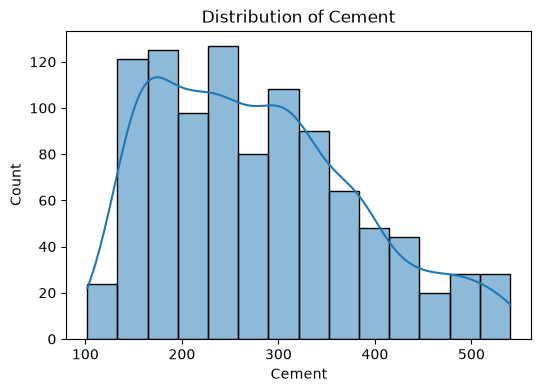

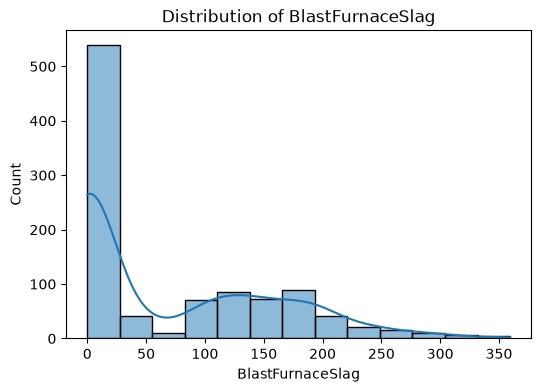

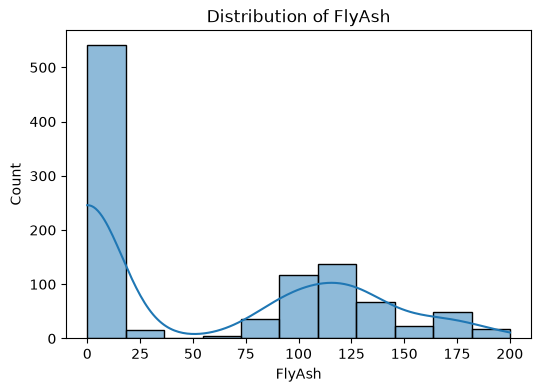

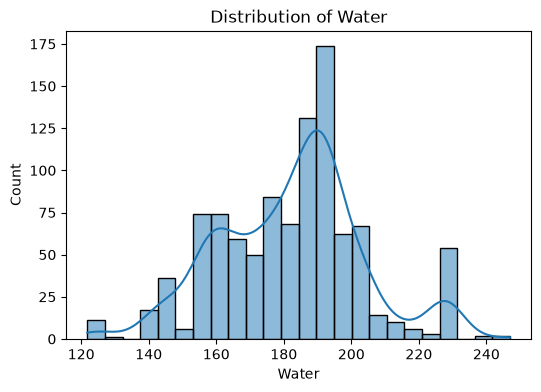

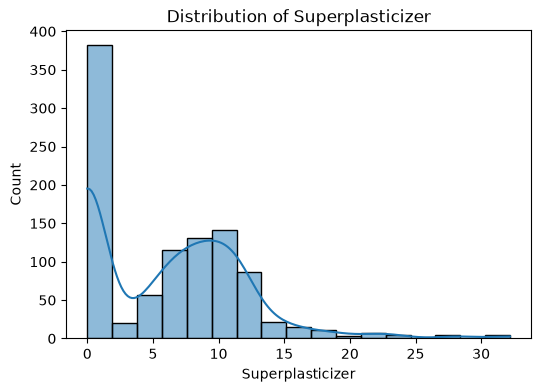

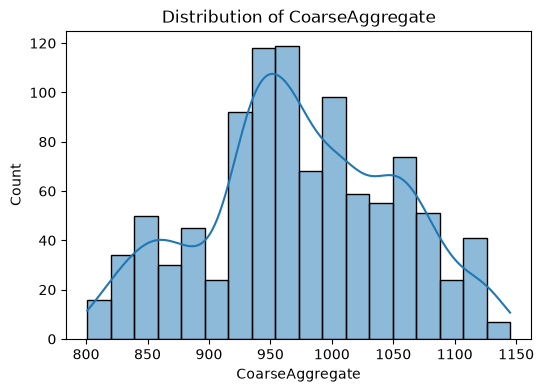

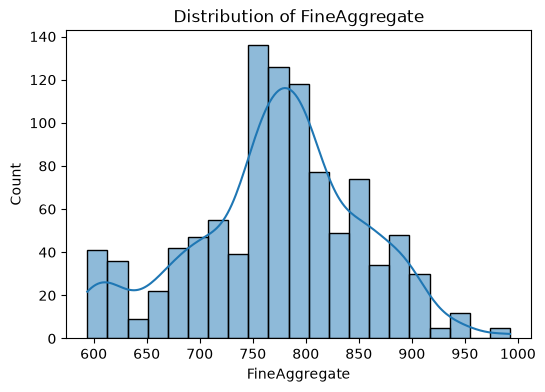

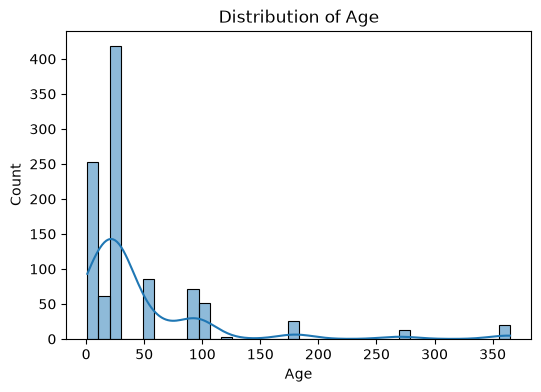

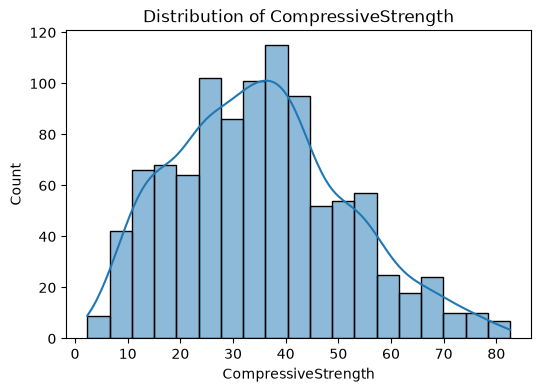

In [8]:
for col in df.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Bivariate Analysis

In [9]:
df.corr()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
Cement,1.000000,-0.303324,-0.385610,-0.056625,0.060906,-0.086205,-0.245375,0.086348,0.488283
BlastFurnaceSlag,-0.303324,1.000000,-0.312352,0.130262,0.019800,-0.277559,-0.289685,-0.042759,0.103374
FlyAsh,-0.385610,-0.312352,1.000000,-0.283314,0.414213,-0.026468,0.090262,-0.158940,-0.080648
Water,-0.056625,0.130262,-0.283314,1.000000,-0.646946,-0.212480,-0.444915,0.279284,-0.269624
Superplasticizer,0.060906,0.019800,0.414213,-0.646946,1.000000,-0.241721,0.207993,-0.194076,0.344209
CoarseAggregate,-0.086205,-0.277559,-0.026468,-0.212480,-0.241721,1.000000,-0.162187,-0.005264,-0.144717
FineAggregate,-0.245375,-0.289685,0.090262,-0.444915,0.207993,-0.162187,1.000000,-0.156572,-0.186448
Age,0.086348,-0.042759,-0.158940,0.279284,-0.194076,-0.005264,-0.156572,1.000000,0.337367
CompressiveStrength,0.488283,0.103374,-0.080648,-0.269624,0.344209,-0.144717,-0.186448,0.337367,1.000000


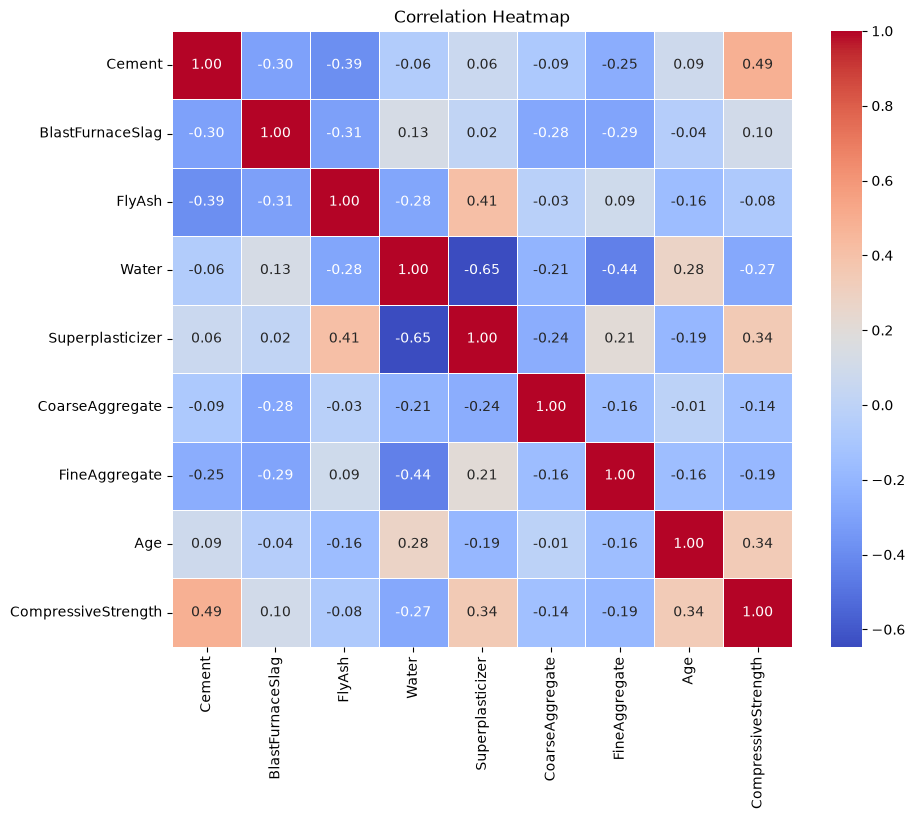

In [10]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

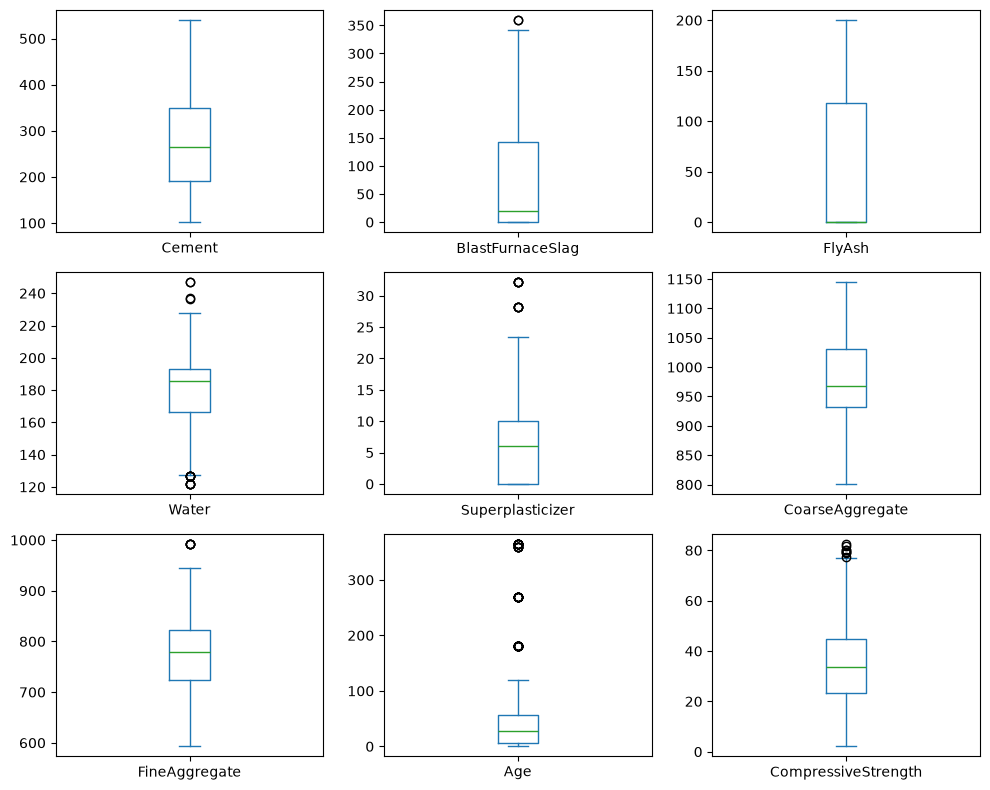

In [11]:
df.plot(kind="box", subplots=True, figsize=(10, 8), layout=(3, 3), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

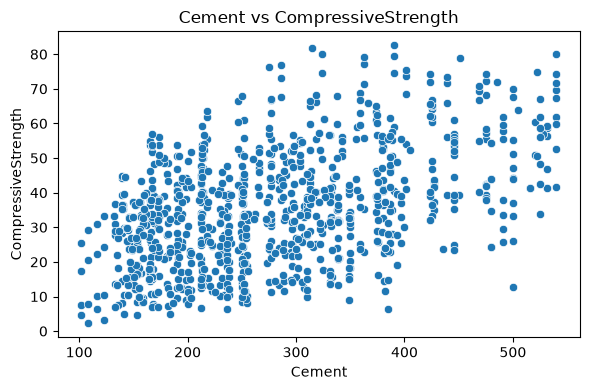

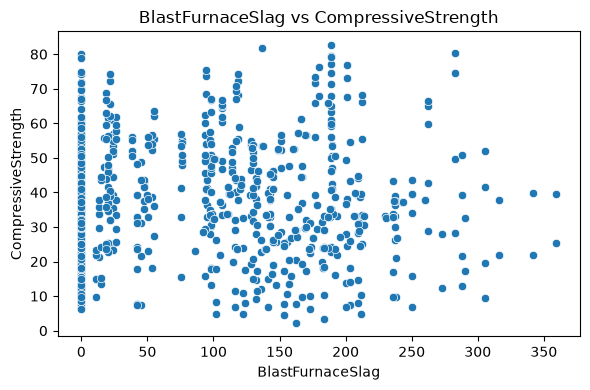

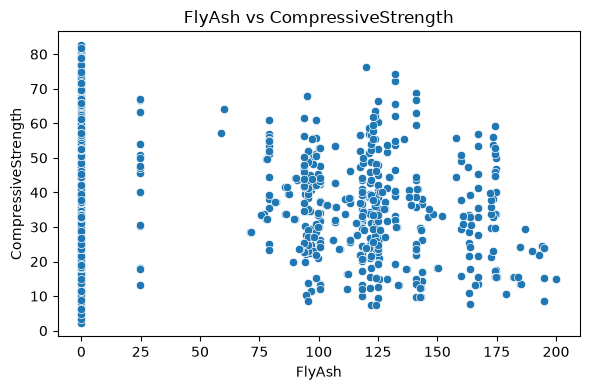

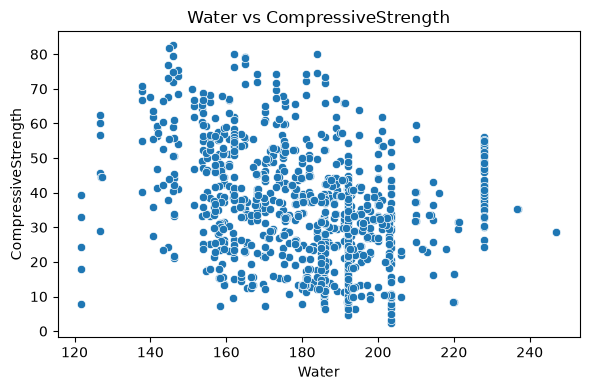

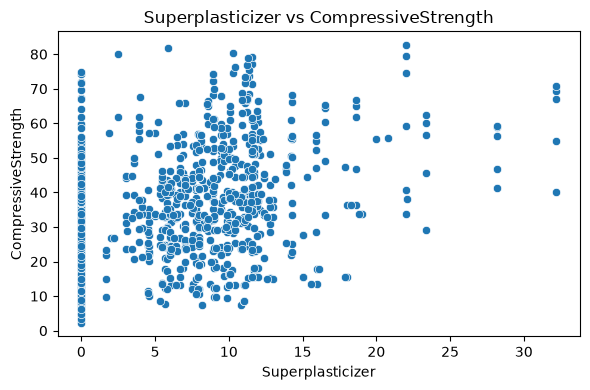

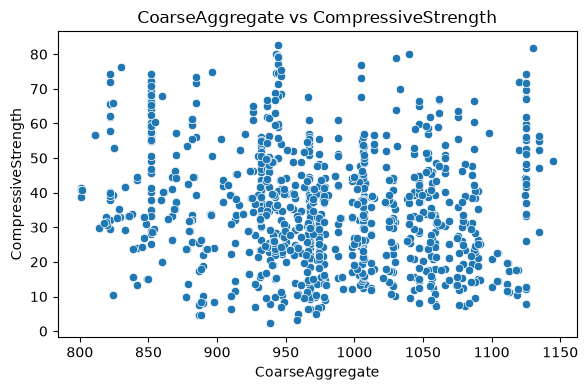

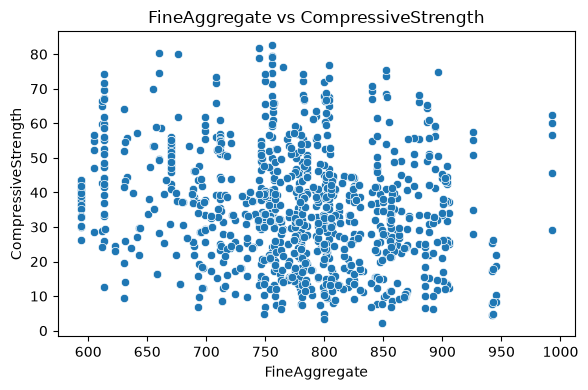

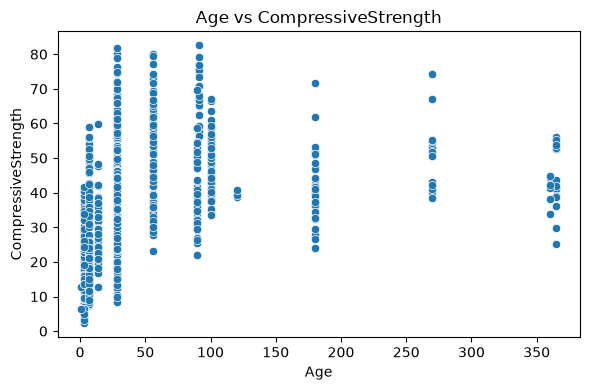

In [12]:
target = "CompressiveStrength"

for col in df.columns:
    if col != target:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(data=df, x=col, y=target)
        plt.title(f"{col} vs {target}")
        plt.tight_layout()
        plt.show()

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Cement               1005 non-null   float64
 1   BlastFurnaceSlag     1005 non-null   float64
 2   FlyAsh               1005 non-null   float64
 3   Water                1005 non-null   float64
 4   Superplasticizer     1005 non-null   float64
 5   CoarseAggregate      1005 non-null   float64
 6   FineAggregate        1005 non-null   float64
 7   Age                  1005 non-null   int64  
 8   CompressiveStrength  1005 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 70.8 KB


# Summary

## Data Quality
1. The dataset contains 1005 observations and 9 input features with no missing values or duplicate.
2. all features are numerical and suitable for regression modeling.



## Univariate Analysis
- Most variables exhibit slight to moderaete right-skewed distributions.
- Several variables, such as Blast Furnace Slag and Fly Ash, contain many  zero values, indicating that these materials are not used in every concrete mix.
- Cement and aggregate variables show relatively wide range, reflecting different mix designs.
- The target variable (compressive strength) spans a broad range, making it suitable for regression.

## Bivariate Analysis
- Age and cement content show positive relationship with compressive strength.
- Water content appears to have a negative relationship with compressive strength.
- Other supplementary materials show weaker or more complex relationship.

## Outliers
- Several variables contain outliers.
- These observations likely represent valid concrete mix designs rather than measurement errors, so they will be retained for modeling.

## 